# CHƯƠNG 2 — THỰC NGHIỆM MACHINE LEARNING CƠ BẢN

**Bài toán:** Nhận dạng chữ số viết tay từ ảnh 8×8 bằng ba thuật toán: **Logistic Regression, Random Forest, SVM**.

**Dữ liệu:** `load_digits()` trong scikit-learn (1.797 ảnh), **không cần tải qua mạng**.

**Mục tiêu hiểu:** dữ liệu → chia train/validation/test → tiền xử lý → huấn luyện → đánh giá Accuracy/Macro-F1 → ma trận nhầm lẫn.

**Phạm vi báo cáo:** Chương 2. Chạy từng ô từ trên xuống (`Shift+Enter`), không cần chạy các notebook khác.

## Bước 1. Import thư viện và cố định hạt giống

`numpy`: xử lý mảng; `pandas`: lập bảng; `matplotlib`: biểu đồ; `sklearn`: thuật toán học máy. Cố định `random_state=42` để có thể chạy lại kết quả.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
OUT = Path('ket_qua')
OUT.mkdir(exist_ok=True)
print('Sẽ lưu kết quả tại:', OUT.resolve())

Sẽ lưu kết quả tại: D:\tlHTTM\Bo_code_Jupyter_Tieu_luan_01\ket_qua


## Bước 2. Tải và khám phá bộ dữ liệu Digits

`images`: kích thước `(1797, 8, 8)`; `target`: nhãn 0–9. Mỗi điểm ảnh có cường độ từ 0 đến 16.

In [2]:
digits = load_digits()
X = digits.images
Y = digits.target
print('Ảnh:', X.shape, '| Nhãn:', Y.shape)
print('Giá trị pixel nhỏ nhất/lớn nhất:', X.min(), X.max())
print('Số lượng theo từng nhãn:')
print(pd.Series(Y).value_counts().sort_index().to_string())

Ảnh: (1797, 8, 8) | Nhãn: (1797,)
Giá trị pixel nhỏ nhất/lớn nhất: 0.0 16.0
Số lượng theo từng nhãn:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180


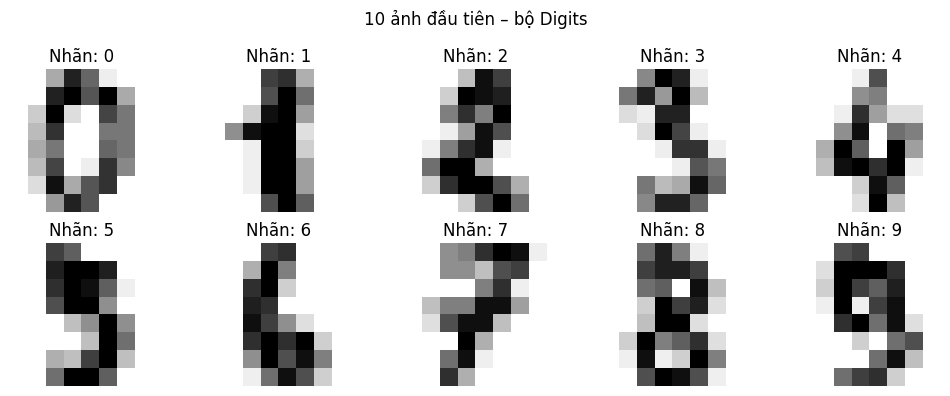

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray_r')
    ax.set_title(f'Nhãn: {Y[i]}')
    ax.axis('off')
fig.suptitle('10 ảnh đầu tiên – bộ Digits')
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong2_anh_mau.png', dpi=160)
plt.close(fig)

## Bước 3. Chia dữ liệu 70% / 15% / 15%

`stratify=Y` giúp giữ tương đối đồng đều tỷ lệ các chữ số trong mỗi tập. **Không lấy dữ liệu test để huấn luyện**.

Ảnh 8×8 được dàn phẳng thành vector 64 đặc trưng (`reshape`) để đưa vào các mô hình ML truyền thống.

In [4]:
indices = np.arange(len(Y))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=Y, random_state=SEED
)
valid_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=Y[temp_idx], random_state=SEED
)
Xflat = X.reshape(len(X), -1)
X_train, X_valid, X_test = Xflat[train_idx], Xflat[valid_idx], Xflat[test_idx]
y_train, y_valid, y_test = Y[train_idx], Y[valid_idx], Y[test_idx]
print('Train:', X_train.shape, 'Valid:', X_valid.shape, 'Test:', X_test.shape)
assert len(set(train_idx) & set(test_idx)) == 0

Train: (1257, 64) Valid: (270, 64) Test: (270, 64)


## Bước 4. Khai báo các mô hình

- **Logistic Regression:** dự đoán xác suất thuộc các lớp chữ số.
- **Random Forest:** kết hợp nhiều cây quyết định.
- **RBF SVM:** dùng ranh giới phân loại phi tuyến.

**Quan trọng:** `StandardScaler()` nằm trong `make_pipeline()`, được `fit` bằng **tập train**, không bị lộ thông tin từ tập test. Random Forest không cần chuẩn hóa.

In [5]:
models = {
    'Logistic regression': make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2500, random_state=SEED)
    ),
    'Random forest': RandomForestClassifier(
        n_estimators=150, max_depth=None, random_state=SEED, n_jobs=1
    ),
    'RBF SVM': make_pipeline(
        StandardScaler(), SVC(C=5.0, gamma='scale', random_state=SEED)
    ),
}
print('Các thuật toán:', list(models))

Các thuật toán: ['Logistic regression', 'Random forest', 'RBF SVM']


## Bước 5. Huấn luyện và đánh giá

`fit(X_train, y_train)` học từ dữ liệu; `predict()` dự đoán. **Accuracy** là tỷ lệ đoán đúng; **Macro F1** là trung bình F1 của 10 lớp, coi các lớp ngang nhau.

Bảng có thêm điểm tập validation để quan sát; ba cấu hình mô hình đã được định trước (không tinh chỉnh dựa trên test).

In [6]:
rows = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    pred_test = model.predict(X_test)
    predictions[name] = pred_test
    row = {
        'Mô hình': name,
        'Validation Accuracy': accuracy_score(y_valid, pred_valid),
        'Test Accuracy': accuracy_score(y_test, pred_test),
        'Test Macro F1': f1_score(y_test, pred_test, average='macro'),
    }
    rows.append(row)
    print(f'{name:22} | Test Accuracy: {row["Test Accuracy"]:.4f} | Macro F1: {row["Test Macro F1"]:.4f}')

summary = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False)
display(summary.round(4))

Logistic regression    | Test Accuracy: 0.9852 | Macro F1: 0.9852
Random forest          | Test Accuracy: 0.9667 | Macro F1: 0.9663
RBF SVM                | Test Accuracy: 0.9889 | Macro F1: 0.9888


,Mô hình,Validation Accuracy,Test Accuracy,Test Macro F1
2,RBF SVM,0.9741,0.9889,0.9888
0,Logistic regression,0.9778,0.9852,0.9852
1,Random forest,0.9630,0.9667,0.9663


## Bước 6. Trực quan kết quả SVM

Ma trận nhầm lẫn: **hàng = nhãn thật**, **cột = nhãn dự đoán**. Ô trên đường chéo chính biểu thị các ảnh được nhận diện đúng.

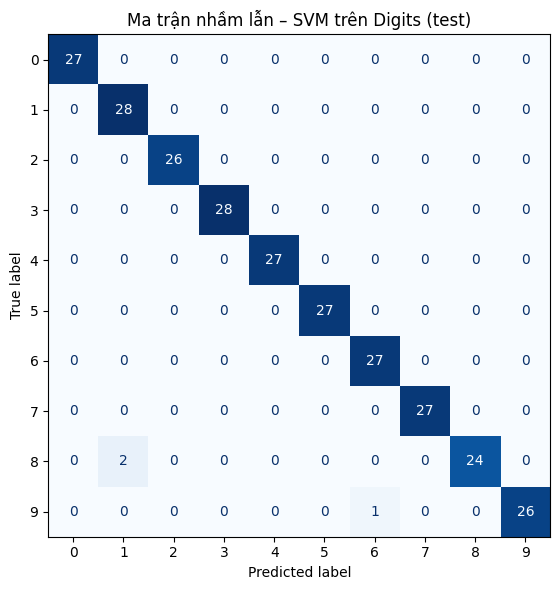

In [7]:
svm_pred = predictions['RBF SVM']
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, svm_pred, labels=np.arange(10))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Ma trận nhầm lẫn – SVM trên Digits (test)')
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong2_ma_tran_nham_lan_svm.png', dpi=160)
plt.close(fig)

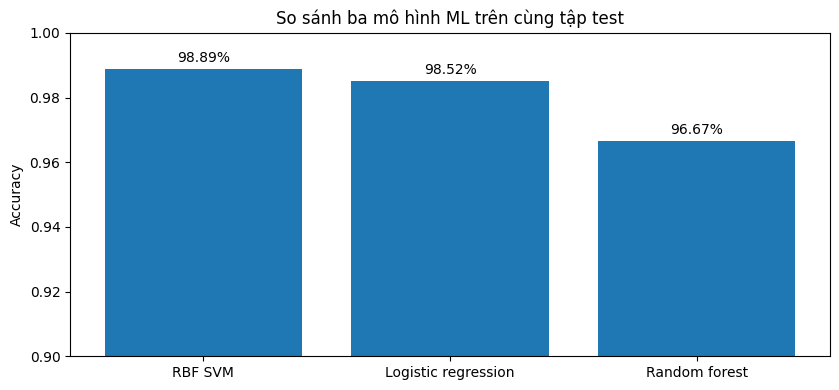

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(summary['Mô hình'], summary['Test Accuracy'])
ax.set_ylim(0.9, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('So sánh ba mô hình ML trên cùng tập test')
for i, v in enumerate(summary['Test Accuracy']):
    ax.text(i, v + 0.002, f'{v:.2%}', ha='center')
fig.tight_layout()
plt.show()
fig.savefig(OUT / 'chuong2_so_sanh_mo_hinh.png', dpi=160)
plt.close(fig)

## Bước 7. Lưu kết quả để đối chiếu với báo cáo

File CSV dùng mở bằng Excel; JSON dùng gộp ở notebook số 04.

In [9]:
summary.to_csv(OUT / 'chuong2_ml_ket_qua.csv', index=False, encoding='utf-8-sig')
ml_result = {
    'seed': SEED,
    'dataset': 'sklearn Digits (1,797 ảnh 8x8)',
    'split': {'train':len(train_idx),'validation':len(valid_idx),'test':len(test_idx)},
    'models': {
        row['Mô hình']: {
            'validation_accuracy': float(row['Validation Accuracy']),
            'test_accuracy': float(row['Test Accuracy']),
            'test_macro_f1': float(row['Test Macro F1']),
        } for row in rows
    },
}
with (OUT / 'chuong2_ml_ket_qua.json').open('w', encoding='utf-8') as f:
    json.dump(ml_result, f, ensure_ascii=False, indent=2)
print('Đã lưu CSV, JSON và hình trong:', OUT.resolve())

Đã lưu CSV, JSON và hình trong: D:\tlHTTM\Bo_code_Jupyter_Tieu_luan_01\ket_qua


## Ghi nhớ khi thuyết trình

**Vì sao SVM có thể tốt hơn CNN?** Digits là ảnh nhỏ, dữ liệu huấn luyện ít; mô hình đơn giản được chuẩn hóa tốt đôi khi tổng quát hóa tốt hơn mạng sâu.

**Tại sao chia tập test?** Để đo chất lượng trên dữ liệu chưa được dùng để học. **Tại sao dùng Macro F1?** Để không chỉ nhìn vào tỷ lệ chính xác tổng thể, mà còn quan tâm từng lớp.